<a href="https://colab.research.google.com/github/2004sreedevip/ML-Lab-/blob/main/ML_Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#breast cancer wisconsin dataset which has malignant and benign
#preprocessing, build two models, decision tree and linear regression, train accuracy recall f1 score, train precision
#give conclusion on which model is best
#if numerical values-missing->replaced by mean, cat missing->mode
#confusion matrix only for testing
#dataset, preprocessing, train and test

In [41]:
import pandas as pd

df = pd.read_csv('/content/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [42]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 569
Number of columns: 33


In [43]:
print(df.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')


In [44]:
print(df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [45]:
df = df.drop(['id', 'Unnamed: 32'], axis=1)

print("Columns after removing unnecessary columns:")
print(df.columns)

Columns after removing unnecessary columns:
Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [46]:
print("Target column: diagnosis")
print("M = Malignant")
print("B = Benign")

print("\nTarget distribution:")
print(df['diagnosis'].value_counts())

Target column: diagnosis
M = Malignant
B = Benign

Target distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [47]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

Categorical columns:
Index(['diagnosis'], dtype='object')


In [48]:
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].mean())

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [49]:

df['diagnosis'] = df['diagnosis'].astype(str).str.strip()

df['diagnosis'] = df['diagnosis'].replace({
    'M': 1,
    'B': 0
})

print(df['diagnosis'].value_counts())

print("\n1 = Malignant")
print("0 = Benign")

diagnosis
0    357
1    212
Name: count, dtype: int64

1 = Malignant
0 = Benign


/tmp/ipykernel_1547/3029319181.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['diagnosis'] = df['diagnosis'].replace({


In [50]:
X = df.drop('diagnosis', axis=1)

y = df['diagnosis']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (398, 30)
Testing data: (171, 30)


In [52]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

print("Decision Tree training completed.")

Decision Tree training completed.


In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_train_pred_dt = dt_model.predict(X_train)

dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)
dt_train_precision = precision_score(y_train, y_train_pred_dt)
dt_train_recall = recall_score(y_train, y_train_pred_dt)
dt_train_f1 = f1_score(y_train, y_train_pred_dt)

print("Decision Tree - Training Results")
print("---------------------------------")
print("Accuracy :", dt_train_accuracy)
print("Precision:", dt_train_precision)
print("Recall   :", dt_train_recall)
print("F1 Score :", dt_train_f1)

Decision Tree - Training Results
---------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Standard scaling completed.")

Standard scaling completed.


In [55]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=10000)

log_model.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [56]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_test_pred_dt)
cm_log = confusion_matrix(y_test, y_test_pred_log)

print("Decision Tree Confusion Matrix:")
print(cm_dt)

print("\nLogistic Regression Confusion Matrix:")
print(cm_log)

Decision Tree Confusion Matrix:
[[100   7]
 [ 10  54]]

Logistic Regression Confusion Matrix:
[[106   1]
 [  9  55]]


In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
y_train_pred_log = log_model.predict(X_train)
log_train_accuracy = accuracy_score(y_train, y_train_pred_log)
log_train_precision = precision_score(y_train, y_train_pred_log)
log_train_recall = recall_score(y_train, y_train_pred_log)
log_train_f1 = f1_score(y_train, y_train_pred_log)

print("Logistic Regression - Training Results")
print("---------------------------------------")
print("Accuracy :", log_train_accuracy)
print("Precision:", log_train_precision)
print("Recall   :", log_train_recall)
print("F1 Score :", log_train_f1)

Logistic Regression - Training Results
---------------------------------------
Accuracy : 0.9623115577889447
Precision: 0.9523809523809523
Recall   : 0.9459459459459459
F1 Score : 0.9491525423728814


In [58]:
y_test_pred_dt = dt_model.predict(X_test)
dt_test_accuracy = accuracy_score(y_test, y_test_pred_dt)
dt_test_precision = precision_score(y_test, y_test_pred_dt)
dt_test_recall = recall_score(y_test, y_test_pred_dt)
dt_test_f1 = f1_score(y_test, y_test_pred_dt)

print("Decision Tree - Testing Results")
print("--------------------------------")
print("Accuracy :", dt_test_accuracy)
print("Precision:", dt_test_precision)
print("Recall   :", dt_test_recall)
print("F1 Score :", dt_test_f1)

Decision Tree - Testing Results
--------------------------------
Accuracy : 0.9005847953216374
Precision: 0.8852459016393442
Recall   : 0.84375
F1 Score : 0.864


In [59]:
from sklearn.metrics import confusion_matrix

y_test_pred_dt = dt_model.predict(X_test)

cm_dt = confusion_matrix(y_test, y_test_pred_dt)

print(cm_dt)

[[100   7]
 [ 10  54]]


In [60]:
y_test_pred_log = log_model.predict(X_test)
log_test_accuracy = accuracy_score(y_test, y_test_pred_log)
log_test_precision = precision_score(y_test, y_test_pred_log)
log_test_recall = recall_score(y_test, y_test_pred_log)
log_test_f1 = f1_score(y_test, y_test_pred_log)

print("Logistic Regression - Testing Results")
print("---------------------------------------")
print("Accuracy :", log_test_accuracy)
print("Precision:", log_test_precision)
print("Recall   :", log_test_recall)
print("F1 Score :", log_test_f1)


Logistic Regression - Testing Results
---------------------------------------
Accuracy : 0.9415204678362573
Precision: 0.9821428571428571
Recall   : 0.859375
F1 Score : 0.9166666666666666


In [61]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test, y_test_pred_log)

print(cm_log)

[[106   1]
 [  9  55]]


In [62]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression'],

    'Train Accuracy (%)': [
        dt_train_accuracy * 100,
        log_train_accuracy * 100
    ],

    'Train Precision (%)': [
        dt_train_precision * 100,
        log_train_precision * 100
    ],

    'Train Recall (%)': [
        dt_train_recall * 100,
        log_train_recall * 100
    ],

    'Train F1 Score (%)': [
        dt_train_f1 * 100,
        log_train_f1 * 100
    ],

    'Test Accuracy (%)': [
        dt_test_accuracy * 100,
        log_test_accuracy * 100
    ],

    'Test Precision (%)': [
        dt_test_precision * 100,
        log_test_precision * 100
    ],

    'Test Recall (%)': [
        dt_test_recall * 100,
        log_test_recall * 100
    ],

    'Test F1 Score (%)': [
        dt_test_f1 * 100,
        log_test_f1 * 100
    ]
})

results.round(2)

,Model,Train Accuracy (%),Train Precision (%),Train Recall (%),Train F1 Score (%),Test Accuracy (%),Test Precision (%),Test Recall (%),Test F1 Score (%)
0,Decision Tree,100.00,100.00,100.00,100.00,90.06,88.52,84.38,86.40
1,Logistic Regression,96.23,95.24,94.59,94.92,94.15,98.21,85.94,91.67


In [63]:
if log_test_f1 > dt_test_f1:
    print("Logistic Regression is the better model.")
elif dt_test_f1 > log_test_f1:
    print("Decision Tree is the better model.")
else:
    print("Both models have the same F1 Score.")

Logistic Regression is the better model.


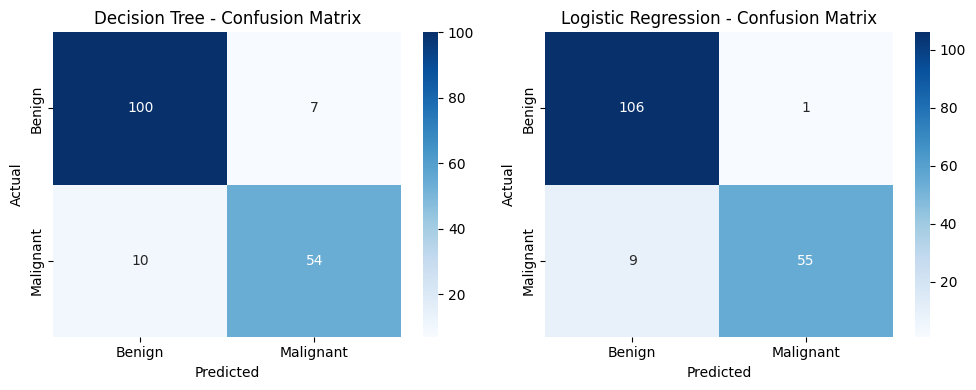

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")

plt.subplot(1,2,2)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.tight_layout()
plt.show()